# Bi-LSTM Training — TensorFlow/Keras (AIVIEW)

TensorFlow port of `bilstm_train.ipynb`. Trains two **separate** bi-LSTM models, one per modality:

- **Audio-only model**: sequence of 15 VGGish embeddings (128-dim each) → input `(batch, 15, 128)`
- **Visual-only model**: sequence of 30 VGG-Face frame embeddings (4096-dim each) → input `(batch, 30, 4096)`

Each model independently predicts the 5 OCEAN personality traits in `[0, 1]` (sigmoid + MSE).

Uses the RTX 4050 GPU with mixed-precision (AMP). *Note:* TensorFlow needs the CUDA libs that ship inside the venv's `nvidia` pip packages, so they are preloaded via `ctypes` before `import tensorflow`.

In [2]:
import os
import site
import glob
import ctypes
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

# ----------------------------------------------------------------------------
# Preload the venv's CUDA libraries (libcudnn, libcublas, ...) before importing
# TensorFlow. Setting LD_LIBRARY_PATH inside the process does not work because
# glibc caches it at interpreter startup.
# ----------------------------------------------------------------------------
cuda_base = os.path.join(site.getsitepackages()[0], 'nvidia')
loaded = []
for lib_dir in sorted(glob.glob(os.path.join(cuda_base, '*', 'lib'))):
    for lib in sorted(glob.glob(os.path.join(lib_dir, '*.so*'))):
        try:
            ctypes.CDLL(lib, mode=os.RTLD_GLOBAL | os.RTLD_LAZY)
            loaded.append(os.path.basename(lib))
        except OSError:
            pass
print(f'preloaded {len(loaded)} CUDA libraries for TensorFlow')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print('TF GPUs:', gpus)
assert gpus, 'TensorFlow could not find a GPU'
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    policy = 'mixed_float16 (AMP)'
except Exception as e:  # fall back to fp32 if cuDNN rejects fp16
    tf.keras.mixed_precision.set_global_policy('float32')
    policy = f'float32 (AMP disabled: {e})'
print('mixed precision policy:', policy)
print('GPU:', tf.test.gpu_device_name())

preloaded 59 CUDA libraries for TensorFlow
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
mixed precision policy: mixed_float16 (AMP)
GPU: /device:GPU:0


In [16]:
# ----------------------------------------------------------------------------
# Hyperparameters & paths
# ----------------------------------------------------------------------------
MODALITIES = {
    'audio': {
        'feature_dir': 'datasets/extracted/Features/audio',
        'seq_len': 15,
        'feat_dim': 128,
        'hidden': 64,
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 32,
        'lr': 1e-4,
        'weight_decay': 1e-5,
        'epochs': 90,
        'patience': 10,
    },
    'visual': {
        'feature_dir': 'datasets/extracted/Features/visual',
        'seq_len': 30,
        'feat_dim': 4096,
        'hidden': 64,
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 32,
        'lr': 1e-4,
        'weight_decay': 1e-5,
        'epochs': 55,
        'patience': 10,
    },
}

LABEL_PKL = {
    'trainingData': 'code_reference/First-Impression/Annotations/annotation_training.pkl',
    'validationData': 'code_reference/First-Impression/Annotations/annotation_validation.pkl',
}

OCEAN = ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

## 1. Load OCEAN labels

The annotation files map `<clip>.mp4` → score in `[0, 1]` for each of the 6 traits. We keep the 5 OCEAN traits (drop `interview`) as the regression targets.

In [5]:
def load_labels(split):
    with open(LABEL_PKL[split], 'rb') as f:
        ann = pickle.load(f, encoding='latin1')
    mapping = {}
    for trait in OCEAN:
        for name, score in ann[trait].items():
            mapping.setdefault(name.replace('.mp4', ''), {})[trait] = float(score)
    return {name: np.array([m[t] for t in OCEAN], dtype=np.float32)
            for name, m in mapping.items()}

LABELS_TRAIN = load_labels('trainingData')
LABELS_VAL = load_labels('validationData')
print('clips with labels -> train:', len(LABELS_TRAIN), '| val:', len(LABELS_VAL))

clips with labels -> train: 6000 | val: 2000


## 2. Load & normalize features

Reads `feature{0..N}.npy` for every clip and stacks them into `(n_clips, seq_len, feat_dim)`.
Incomplete clips (wrong number of frames/segments) are skipped.
Features are z-score normalized **per feature-dimension using training-set statistics only**.

In [7]:
def load_features(split, mod):
    cfg = MODALITIES[mod]
    root = Path(cfg['feature_dir']) / split
    clips, arrays = [], []
    dirs = sorted(root.iterdir())
    for clip_dir in tqdm(dirs, desc=f'load {mod}/{split}', leave=False):
        if not clip_dir.is_dir():
            continue
        try:
            stack = [np.load(clip_dir / f'feature{i}.npy', allow_pickle=False)
                     for i in range(cfg['seq_len'])]
        except (FileNotFoundError, OSError):
            continue
        arr = np.stack(stack, axis=0).astype(np.float32)
        if arr.shape != (cfg['seq_len'], cfg['feat_dim']):
            continue
        arrays.append(arr)
        clips.append(clip_dir.name)
    return clips, np.stack(arrays, axis=0)


def build_dataset(mod, verbose=True):
    cfg = MODALITIES[mod]

    tr_clips, tr_X = load_features('trainingData', mod)
    va_clips, va_X = load_features('validationData', mod)

    tr_keep = [i for i, c in enumerate(tr_clips) if c in LABELS_TRAIN]
    va_keep = [i for i, c in enumerate(va_clips) if c in LABELS_VAL]
    tr_clips = [tr_clips[i] for i in tr_keep]
    tr_X = tr_X[tr_keep]
    va_clips = [va_clips[i] for i in va_keep]
    va_X = va_X[va_keep]

    mean = tr_X.mean(axis=(0, 1), keepdims=True)
    std = tr_X.std(axis=(0, 1), keepdims=True) + 1e-8
    tr_X = (tr_X - mean) / std
    va_X = (va_X - mean) / std

    tr_y = np.stack([LABELS_TRAIN[c] for c in tr_clips], axis=0)
    va_y = np.stack([LABELS_VAL[c] for c in va_clips], axis=0)

    if verbose:
        print(f'[{mod}] train: {tr_X.shape} -> labels {tr_y.shape} | '
              f'val: {va_X.shape} -> labels {va_y.shape}')

    return (tr_X, tr_y), (va_X, va_y)

## 3. Model definition

Bidirectional LSTM over the feature sequence (Keras `return_sequences=False` keeps the last forward+backward
hidden states) followed by a small MLP head producing 5 sigmoid outputs (one per OCEAN trait).

In [8]:
def build_model(feat_dim, hidden, num_layers=1, dropout=0.3, seq_len=None):
    inp = tf.keras.Input(shape=(seq_len, feat_dim))
    x = inp
    for layer in range(num_layers):
        return_seq = num_layers > 1 and layer < num_layers - 1
        x = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(hidden, return_sequences=return_seq))(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(5, activation='sigmoid', name='ocean_output')(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, weight_decay=1e-5),
        loss='mse',
        metrics=['mae'],
    )
    return model

## 4. Training / evaluation utilities

- Loss: MSE on sigmoid outputs; metric: MAE.
- Early stopping on **validation MAE** with `restore_best_weights=True`.
- Models saved to `models/bilstm_<modality>_tf.keras` + per-trait val MAE and history JSON.

In [9]:
def train_model(mod):
    cfg = MODALITIES[mod]

    (Xtr, ytr), (Xva, yva) = build_dataset(mod)
    train_ds = (tf.data.Dataset.from_tensor_slices((Xtr, ytr))
                .shuffle(len(Xtr)).batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((Xva, yva))
              .batch(cfg['batch_size']).prefetch(tf.data.AUTOTUNE))

    model = build_model(cfg['feat_dim'], cfg['hidden'], cfg['num_layers'],
                        cfg['dropout'], cfg['seq_len'])

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=cfg['patience'],
        restore_best_weights=True, verbose=1)

    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=cfg['epochs'], callbacks=[early_stop], verbose=2)

    hist = history.history
    best_idx = int(np.argmin(hist['val_mae']))
    best_epoch = best_idx + 1
    best_mae = float(hist['val_mae'][best_idx])

    pred = model.predict(val_ds, verbose=0)
    mae_per_trait = np.mean(np.abs(pred - yva), axis=0)

    ckpt_path = MODEL_DIR / f'bilstm_{mod}_tf.keras'
    model.save(ckpt_path)

    meta = {'modality': mod, 'best_epoch': best_epoch, 'best_va_mae': best_mae,
            'val_mae_per_trait': [float(m) for m in mae_per_trait], 'traits': OCEAN,
            'config': {k: v for k, v in cfg.items() if isinstance(v, (int, float, str))},
            'history': {k: [float(x) for x in v] for k, v in hist.items()}}
    with open(MODEL_DIR / f'bilstm_{mod}_tf_history.json', 'w') as f:
        json.dump(meta, f, indent=2)

    epochs = history.epoch
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist['loss'], label='train')
    axes[0].plot(epochs, hist['val_loss'], label='val')
    axes[0].set_title(f'{mod} loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
    axes[1].plot(epochs, hist['mae'], label='train')
    axes[1].plot(epochs, hist['val_mae'], label='val')
    axes[1].set_title(f'{mod} MAE'); axes[1].set_xlabel('epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

    print(f'\n[{mod}] BEST val MAE = {best_mae:.4f} at epoch {best_epoch}')
    for t, m in zip(OCEAN, mae_per_trait):
        print(f'    {t:16s} MAE = {m:.4f}')
    print(f'    saved: {ckpt_path}')
    return meta

## 5. Train audio-only bi-LSTM

Input: the 15 VGGish segment embeddings per clip. **Audio training runs independently** — it does not use any visual data.

load audio/trainingData:   0%|          | 0/1200 [00:00<?, ?it/s]

[audio] train: (1190, 15, 128) -> labels (1190, 5) | val: (398, 15, 128) -> labels (398, 5)
Epoch 1/90


38/38 - 2s - 44ms/step - loss: 0.0347 - mae: 0.1494 - val_loss: 0.0248 - val_mae: 0.1254
Epoch 2/90
38/38 - 0s - 9ms/step - loss: 0.0297 - mae: 0.1379 - val_loss: 0.0221 - val_mae: 0.1179
Epoch 3/90
38/38 - 0s - 9ms/step - loss: 0.0274 - mae: 0.1328 - val_loss: 0.0206 - val_mae: 0.1141
Epoch 4/90
38/38 - 0s - 10ms/step - loss: 0.0255 - mae: 0.1281 - val_loss: 0.0196 - val_mae: 0.1115
Epoch 5/90
38/38 - 0s - 11ms/step - loss: 0.0242 - mae: 0.1246 - val_loss: 0.0189 - val_mae: 0.1095
Epoch 6/90
38/38 - 0s - 11ms/step - loss: 0.0227 - mae: 0.1200 - val_loss: 0.0183 - val_mae: 0.1080
Epoch 7/90
38/38 - 0s - 11ms/step - loss: 0.0218 - mae: 0.1185 - val_loss: 0.0179 - val_mae: 0.1067
Epoch 8/90
38/38 - 0s - 8ms/step - loss: 0.0222 - mae: 0.1192 - val_loss: 0.0175 - val_mae: 0.1058
Epoch 9/90
38/38 - 0s - 10ms/step - loss: 0.0210 - mae: 0.1159 - val_loss: 0.0173 - val_mae: 0.1050
Epoch 10/90
38/38 - 0s - 11ms/step - loss: 0.0203 - mae: 0.1140 - val_loss: 0.0170 - val_mae: 0.1043
Epoch 11/90
3

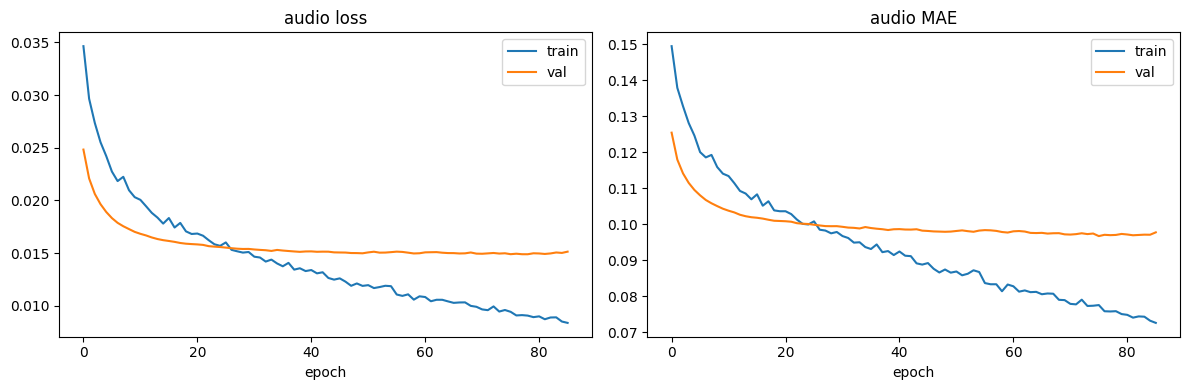


[audio] BEST val MAE = 0.0967 at epoch 76
    extraversion     MAE = 0.0992
    neuroticism      MAE = 0.0927
    agreeableness    MAE = 0.0914
    conscientiousness MAE = 0.1065
    openness         MAE = 0.0937
    saved: models/bilstm_audio_tf.keras


In [17]:
audio_result = train_model('audio')

## 6. Train visual-only bi-LSTM

Input: the 30 VGG-Face frame embeddings per clip. **Visual training runs separately** from audio.

[visual] train: (1200, 30, 4096) -> labels (1200, 5) | val: (400, 30, 4096) -> labels (400, 5)
Epoch 1/55
38/38 - 2s - 60ms/step - loss: 0.0415 - mae: 0.1631 - val_loss: 0.0273 - val_mae: 0.1322
Epoch 2/55
38/38 - 1s - 13ms/step - loss: 0.0284 - mae: 0.1351 - val_loss: 0.0234 - val_mae: 0.1215
Epoch 3/55
38/38 - 1s - 14ms/step - loss: 0.0221 - mae: 0.1185 - val_loss: 0.0216 - val_mae: 0.1163
Epoch 4/55
38/38 - 1s - 14ms/step - loss: 0.0194 - mae: 0.1110 - val_loss: 0.0202 - val_mae: 0.1121
Epoch 5/55
38/38 - 1s - 14ms/step - loss: 0.0164 - mae: 0.1013 - val_loss: 0.0190 - val_mae: 0.1081
Epoch 6/55
38/38 - 1s - 16ms/step - loss: 0.0155 - mae: 0.0983 - val_loss: 0.0184 - val_mae: 0.1061
Epoch 7/55
38/38 - 1s - 14ms/step - loss: 0.0136 - mae: 0.0920 - val_loss: 0.0180 - val_mae: 0.1052
Epoch 8/55
38/38 - 1s - 17ms/step - loss: 0.0125 - mae: 0.0885 - val_loss: 0.0177 - val_mae: 0.1044
Epoch 9/55
38/38 - 1s - 15ms/step - loss: 0.0125 - mae: 0.0877 - val_loss: 0.0174 - val_mae: 0.1036
Epoch

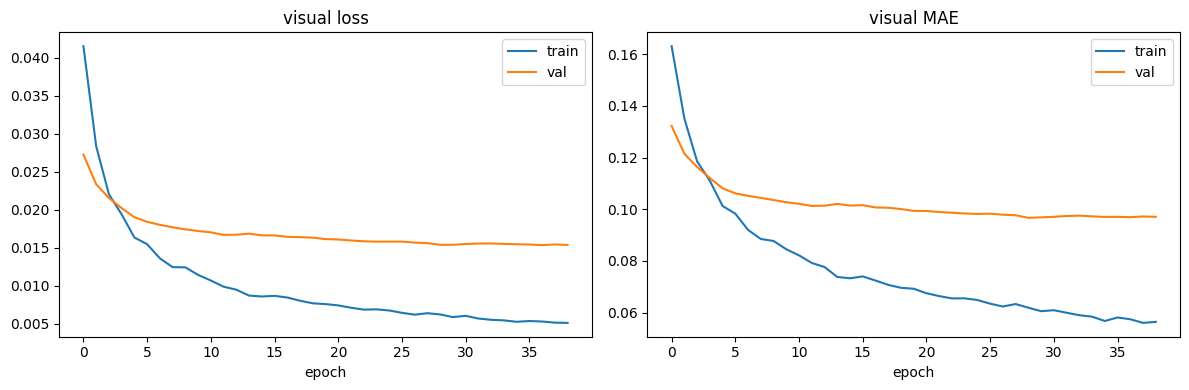


[visual] BEST val MAE = 0.0967 at epoch 29
    extraversion     MAE = 0.0972
    neuroticism      MAE = 0.0975
    agreeableness    MAE = 0.0923
    conscientiousness MAE = 0.0930
    openness         MAE = 0.1033
    saved: models/bilstm_visual_tf.keras


In [18]:
visual_result = train_model('visual')

## 7. Result summary

Final validation MAE (overall + per OCEAN trait) for both modalities, plus where each model is saved.

In [ ]:
results = []
for mod in MODALITIES:
    with open(MODEL_DIR / f'bilstm_{mod}_tf_history.json') as f:
        results.append(json.load(f))

print(f"{'modality':<8} | {'best val MAE':<13} | " + ' | '.join(f'{t[:4]}' for t in OCEAN))
print('-' * (8 + 15 + 5 * len(OCEAN)))
for r in results:
    per = r['val_mae_per_trait']
    print(f"{r['modality']:<8} | {r['best_va_mae']:<13.4f} | " + ' | '.join(f'{m:.3f}' for m in per))
    print(f"    best epoch: {r['best_epoch']}  ->  models/bilstm_{r['modality']}_tf.keras")